***Groupby***
>Gerçek hayatta veriler ham gelir. 
>Mesela bir e-ticaret şirketinde şu soruyu sorarsın: "Her kategorinin toplam satışı ne kadar?" 
>Ya da: "Her müşteri ortalama kaç sipariş veriyor?"

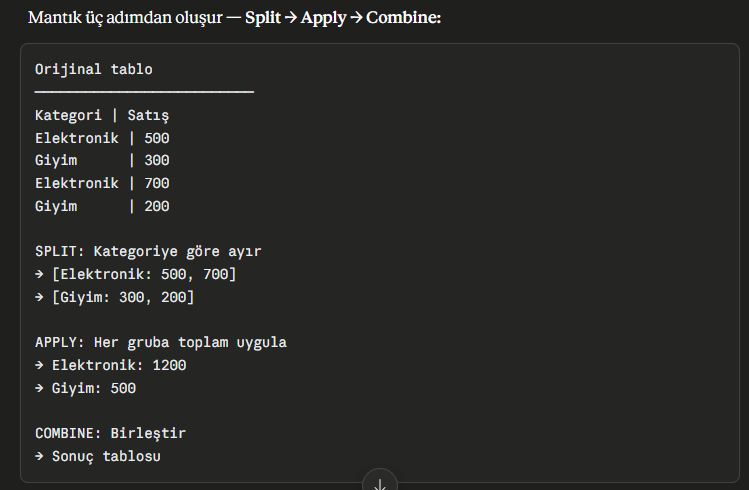

In [2]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'category': ['Elektronik', 'Giyim', 'Elektronik', 'Giyim', 'Gida'],
    'sales':    [500, 300, 700, 200, 150],
    'pcs':     [2, 5, 3, 4, 1]
})

In [9]:
df.groupby('category').sum()

,sales,pcs
category,,
Elektronik,1200,5
Gida,150,1
Giyim,500,9


In [11]:
df.groupby('category')['sales'].sum()

category
Elektronik    1200
Gida           150
Giyim          500
Name: sales, dtype: int64

In [20]:
df.groupby('category').agg({'sales': 'sum',})

,sales
category,
Elektronik,1200
Gida,150
Giyim,500


In [21]:
df.groupby('category').agg(mean_pcs=('pcs', 'mean'))

,mean_pcs
category,
Elektronik,2.5
Gida,1.0
Giyim,4.5


In [16]:
df.groupby('category').agg(
    total_sales=('sales', 'sum'),
    mean_sales=('sales', 'mean'),
    total_pcs=('pcs', 'sum') )

,total_sales,mean_sales,total_pcs
category,,,
Elektronik,1200,600.0,5
Gida,150,150.0,1
Giyim,500,250.0,9


In [ ]:
df.groupby(['category', 'pcs'])['sales'].sum()

: 

In [15]:
df_city = pd.DataFrame({
    "customer_id": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "city": ["Istanbul", "Ankara", "Izmir", "Istanbul", "Ankara", "Ankara", "Ankara", "Izmir", "Istanbul", "Izmir"],
    "order_total": [100, 150, 200, 250, 300, 350, 400, 450, 500, 550],
    "date": pd.to_datetime(["2024-01-01", "2024-01-02", "2024-01-03", "2024-01-04", "2024-01-05", "2024-01-06", "2024-01-07", "2024-01-08", "2024-01-09", "2024-01-10"])
})

In [16]:
df_city.groupby('city')['order_total'].sum().sort_values(ascending=False)

city
Ankara      1200
Izmir       1200
Istanbul     850
Name: order_total, dtype: int64

In [ ]:
# idxmax() : en yüksek değere sahip index'i döndürür.
# count, mean, sum <=== aggregations
df_city.groupby('city')['order_total'].count().sort_values(ascending=True).idxmax()
df_city.groupby('city')['order_total'].count().sort_values(ascending=True).idxmin()
df_city.groupby('city')['order_total'].count()


city
Ankara      4
Istanbul    3
Izmir       3
Name: order_total, dtype: int64

In [13]:
df_city.groupby('city').agg(
    total_order=('order_total', 'sum'),
    mean_order=('order_total', 'mean'),)

,total_order,mean_order
city,,
Ankara,450,225.0
Istanbul,350,175.0
Izmir,200,200.0


In [27]:
df_company = pd.DataFrame({
    "employee_name": ["Alice", "Bob", "Charlie", "David", "Eve", "Alice", "Bob", "Charlie", "David", "Eve"],
    "department": ["HR", "IT", "HR", "IT", "Finance", "HR", "IT", "HR", "IT", "Finance"],
    'salary': [50000, 60000, 55000, 65000, 70000, 90000, 50000, 40000, 75000, 50000] })

In [41]:
#transform <=== orijinal tablonun şeklini korur, her satıra grubunun değerini yapıştırır.
# Her çalışan kendi satırında kaldı, ama yanına departman ortalaması eklendi. 
# Bu feature engineering'de çok kullanılır — "bu kişi departman ortalamasının ne kadar üstünde?" 
# gibi yeni bir feature üretmek için.
# groupby.mean() ==> gruplari kucultur, N sayidan K sayiya iner



df_company['avg_salary'] = df_company.groupby('department')['salary'].transform('mean')

df_company


,employee_name,department,salary,avg_salary
0,Alice,HR,50000,58750.0
1,Bob,IT,60000,62500.0
2,Charlie,HR,55000,58750.0
3,David,IT,65000,62500.0
4,Eve,Finance,70000,60000.0
5,Alice,HR,90000,58750.0
6,Bob,IT,50000,62500.0
7,Charlie,HR,40000,58750.0
8,David,IT,75000,62500.0
9,Eve,Finance,50000,60000.0


In [ ]:
# to see difference between salary and department average salary
df_company['difference'] = df_company['salary'] - df_company.groupby('department')['salary'].transform('mean')


df_company  

,employee_name,department,salary,avg_salary,difference
0,Alice,HR,50000,58750.0,-8750.0
1,Bob,IT,60000,62500.0,-2500.0
2,Charlie,HR,55000,58750.0,-3750.0
3,David,IT,65000,62500.0,2500.0
4,Eve,Finance,70000,60000.0,10000.0
5,Alice,HR,90000,58750.0,31250.0
6,Bob,IT,50000,62500.0,-12500.0
7,Charlie,HR,40000,58750.0,-18750.0
8,David,IT,75000,62500.0,12500.0
9,Eve,Finance,50000,60000.0,-10000.0


> filter → koşulu gruba uygular, koşulu sağlayan grubun tüm satırlarını döndürür.

In [58]:
# df[df[col] > 50000] ===> normal filter satir bazinda filtreler

normal_filter = df_company[df_company['salary'] > 59000]

#filter() ===> aggreagation. group bazinda filtirler


# Senaryo: Ortalama maaşı 5000'in üzerinde olan departmanları getir — ama tüm çalışanları görmek istiyorum, 
# sadece departman adını değil.
group_filter = df_company.groupby('department').filter(lambda x: x['salary'].mean() > 59000)

print(normal_filter)
print(group_filter)

  employee_name department  salary  avg_salary  difference
1           Bob         IT   60000     62500.0     -2500.0
3         David         IT   65000     62500.0      2500.0
4           Eve    Finance   70000     60000.0     10000.0
5         Alice         HR   90000     58750.0     31250.0
8         David         IT   75000     62500.0     12500.0
  employee_name department  salary  avg_salary  difference
1           Bob         IT   60000     62500.0     -2500.0
3         David         IT   65000     62500.0      2500.0
4           Eve    Finance   70000     60000.0     10000.0
6           Bob         IT   50000     62500.0    -12500.0
8         David         IT   75000     62500.0     12500.0
9           Eve    Finance   50000     60000.0    -10000.0
